# 03 - Capitulation probes (Q3)

Loads `runs/probes_first_logistic.csv` (produced by `scripts/train_probes.py --use-turn first`) and:

1. Plots **balanced accuracy** and **AUC** by layer, faceted by victim.
2. Reports the layers where the probe is significant (permutation `p < 0.05/n_layers` Bonferroni).
3. Cross-victim comparison: at what depth does capitulation become decodable?

Probes use **`class_weight='balanced'`** so Llama's 70/30 class imbalance does
not collapse predictions to the majority class. Headline metrics are AUC and
balanced accuracy; raw accuracy is reported for completeness.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RUNS_DIR = pathlib.Path('../../runs')
df = pd.read_csv(RUNS_DIR / 'probes_first_logistic.csv')
df['victim'] = df['run_dir'].str.split('/').str[-1].str.replace('_v1', '')
df.head()

,layer,accuracy,balanced_accuracy,f1,auc,majority,permutation_p,n,n_pos,tag,run_dir,victim
0,1,0.6150,0.595150,0.457598,0.616828,0.7025,0.000,400,119,early,runs/llama_v1,llama
1,2,0.5825,0.596083,0.472469,0.613260,0.7025,0.000,400,119,early,runs/llama_v1,llama
2,3,0.5875,0.597273,0.472664,0.630516,0.7025,0.000,400,119,early,runs/llama_v1,llama
3,4,0.5825,0.591321,0.466164,0.629485,0.7025,0.000,400,119,early,runs/llama_v1,llama
4,5,0.5625,0.569892,0.442214,0.630538,0.7025,0.015,400,119,early,runs/llama_v1,llama


## 1. Probe AUC and balanced accuracy by layer

AUC is the cleanest measure of separability under class imbalance; balanced accuracy is the second-best summary.

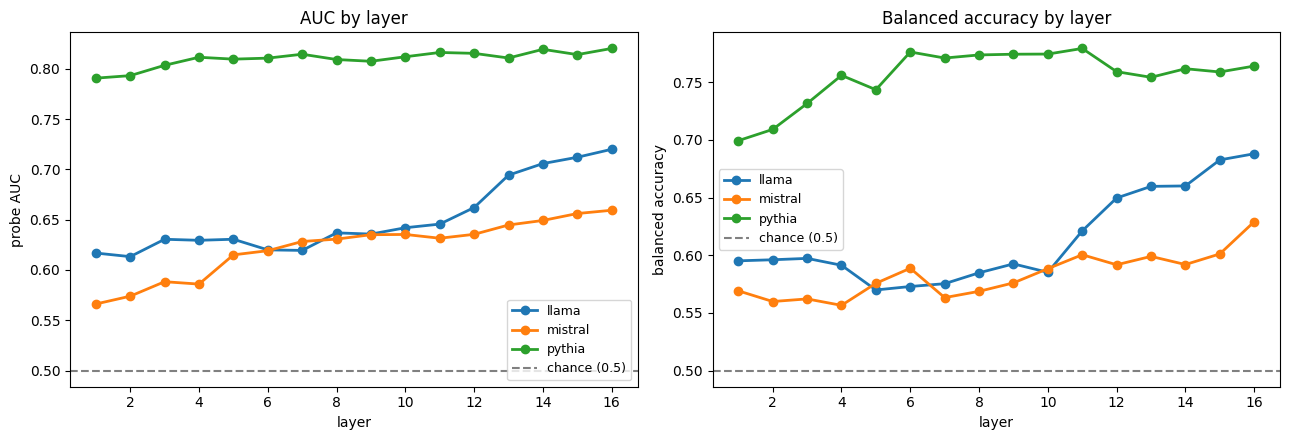

In [2]:
victims = sorted(df['victim'].unique())
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
for victim in victims:
    sub = df[df['victim'] == victim].sort_values('layer')
    axes[0].plot(sub['layer'], sub['auc'], marker='o', label=victim, linewidth=2)
    axes[1].plot(sub['layer'], sub['balanced_accuracy'], marker='o', label=victim, linewidth=2)
axes[0].axhline(0.5, ls='--', color='gray', label='chance (0.5)')
axes[1].axhline(0.5, ls='--', color='gray', label='chance (0.5)')
axes[0].set_xlabel('layer'); axes[0].set_ylabel('probe AUC')
axes[1].set_xlabel('layer'); axes[1].set_ylabel('balanced accuracy')
axes[0].set_title('AUC by layer'); axes[1].set_title('Balanced accuracy by layer')
axes[0].legend(fontsize=9); axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig(RUNS_DIR / 'fig_probe_by_layer.png', dpi=130, bbox_inches='tight')
plt.show()

## 2. Significance table (Bonferroni-corrected)

Layers where the probe is significantly better than chance after adjusting for multiple comparisons (alpha = 0.05 / N_layers per victim).

In [3]:
rows = []
for victim, sub in df.groupby('victim'):
    alpha = 0.05 / len(sub)
    sig = sub[sub['permutation_p'] < alpha]
    rows.append({
        'victim': victim,
        'n_layers_total': len(sub),
        'n_layers_sig': len(sig),
        'best_layer': int(sub.loc[sub['auc'].idxmax(), 'layer']),
        'best_auc': float(sub['auc'].max()),
        'best_bal_acc': float(sub.loc[sub['auc'].idxmax(), 'balanced_accuracy']),
        'best_f1': float(sub.loc[sub['auc'].idxmax(), 'f1']),
        'majority_baseline': float(sub['majority'].iloc[0]),
    })
summary = pd.DataFrame(rows)
print('Per-victim summary:')
print(summary.to_string(index=False))

Per-victim summary:
 victim  n_layers_total  n_layers_sig  best_layer  best_auc  best_bal_acc  best_f1  majority_baseline
  llama              16            10          16  0.719937      0.687955 0.568594             0.7025
mistral              16            12          16  0.659348      0.629044 0.649491             0.5175
 pythia              16            16          16  0.820138      0.763977 0.777025             0.5125


## 3. Where does capitulation become decodable?

First layer at which the probe's AUC exceeds 0.65 (a moderate-effect threshold). For instruction-tuned models we expect this to be later in the network than for base models.

In [4]:
for victim, sub in df.groupby('victim'):
    sub = sub.sort_values('layer')
    above = sub[sub['auc'] > 0.65]
    if len(above) == 0:
        print(f'{victim}: AUC never exceeds 0.65')
    else:
        first = int(above.iloc[0]['layer'])
        print(f'{victim}: first layer with AUC > 0.65 is layer {first}'
              f' (AUC = {above.iloc[0]["auc"]:.3f})')

llama: first layer with AUC > 0.65 is layer 12 (AUC = 0.662)
mistral: first layer with AUC > 0.65 is layer 15 (AUC = 0.656)
pythia: first layer with AUC > 0.65 is layer 1 (AUC = 0.791)
